In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp as scipy_logsumexp
import ld

# Global settings for publication quality
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15

np.random.seed(42)
eps = 1e-5

# Higher-Order Interactions

In [2]:
S = (28, 28)

def create_enhanced_separable_image(size=28):
    """Enhanced separable image with stronger visual patterns"""
    i = np.arange(size)
    j = np.arange(size)

    # Use strong, simple patterns for clarity
    row_effect = 1 + 1.2 * np.sin(2 * np.pi * 3 * i / size)
    col_effect = 1 + 1.2 * np.cos(2 * np.pi * 3 * j / size)

    img = 100 * row_effect[:, np.newaxis] * col_effect[np.newaxis, :]
    return np.maximum(img, 1.0) + eps

def create_enhanced_nonseparable_image(size=28):
    """Enhanced non-separable image with VERY STRONG visible interactions"""
    i = np.arange(size)
    j = np.arange(size)

    # Weaker separable base
    row_effect = 1 + 0.3 * np.sin(2 * np.pi * 2 * i / size)
    col_effect = 1 + 0.3 * np.cos(2 * np.pi * 2 * j / size)
    img_separable = 30 * row_effect[:, np.newaxis] * col_effect[np.newaxis, :]

    # STRONG interaction terms
    II, JJ = np.meshgrid(i, j, indexing='ij')

    # Diagonal checkerboard pattern (very visible 2-body interaction)
    checkerboard = np.sin(2 * np.pi * (II + JJ) / 8)

    # Cross-diagonal pattern
    cross_pattern = np.cos(2 * np.pi * (II - JJ) / 12)

    # Radial interaction from center
    center_i, center_j = size / 2, size / 2
    radial = np.sqrt((II - center_i)**2 + (JJ - center_j)**2)
    radial_pattern = np.sin(2 * np.pi * radial / size)

    # Combine with STRONG weights
    img = img_separable * (1 + 0.8 * checkerboard + 0.6 * cross_pattern + 0.5 * radial_pattern)

    img = np.maximum(img, 1.0)
    return img + eps

# Generate enhanced examples
X_sep_enhanced = create_enhanced_separable_image(S[0])
X_nonsep_enhanced = create_enhanced_nonseparable_image(S[0])

# --- Define Bases ---
B_1body = ld.default_B(S, 1, np)
B_2body = ld.default_B(S, 2, np)

# Approximate both
_, _, s1_sep_enh, Q1_sep_enh, _ = ld.LD(X_sep_enhanced, B=B_1body, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
approx_1body_sep_enh = Q1_sep_enh * s1_sep_enh

_, _, s2_sep_enh, Q2_sep_enh, _ = ld.LD(X_sep_enhanced, B=B_2body, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
approx_2body_sep_enh = Q2_sep_enh * s2_sep_enh

_, _, s1_nonsep_enh, Q1_nonsep_enh, _ = ld.LD(X_nonsep_enhanced, B=B_1body, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
approx_1body_nonsep_enh = Q1_nonsep_enh * s1_nonsep_enh

_, _, s2_nonsep_enh, Q2_nonsep_enh, _ = ld.LD(X_nonsep_enhanced, B=B_2body, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
approx_2body_nonsep_enh = Q2_nonsep_enh * s2_nonsep_enh

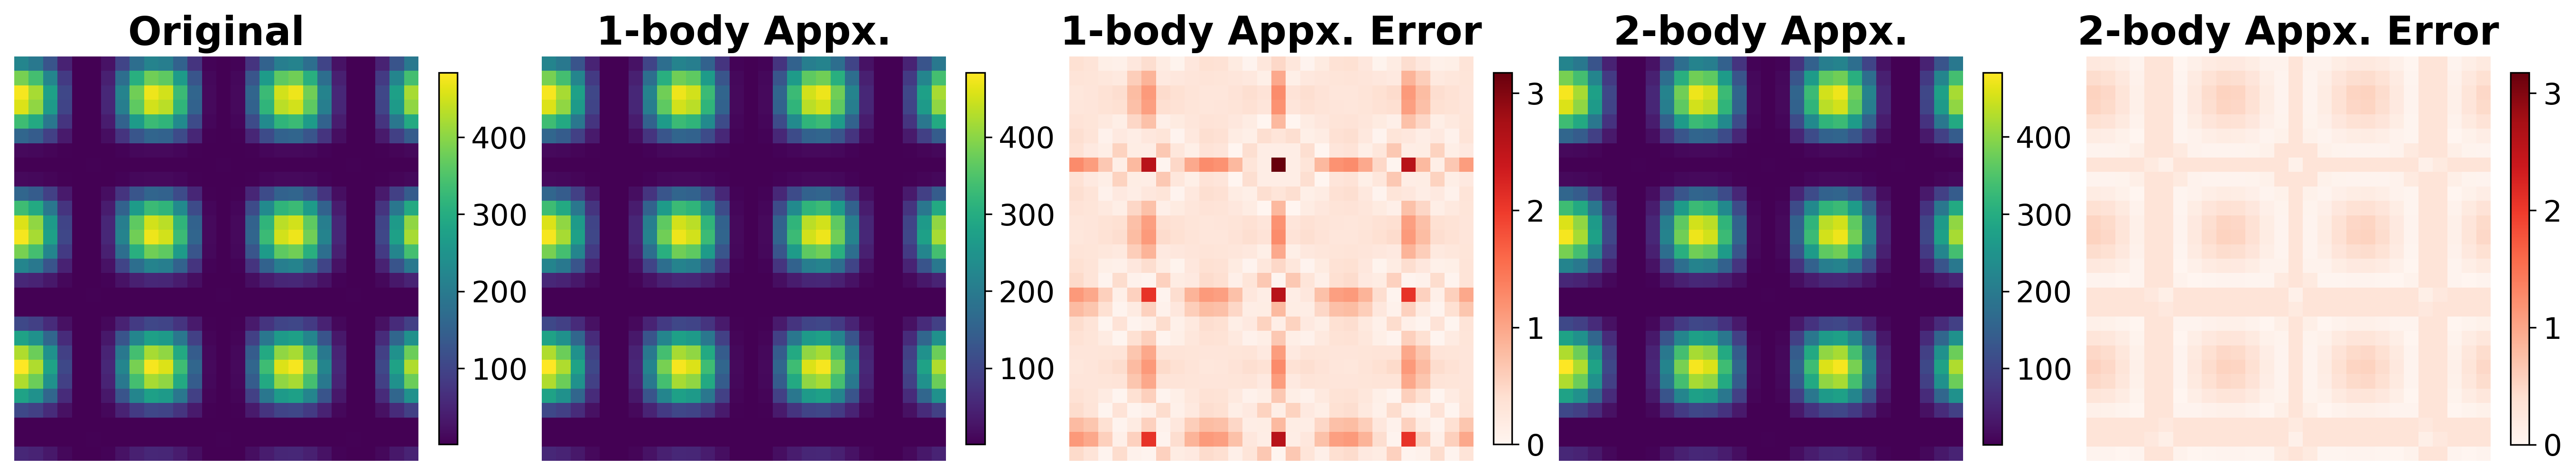

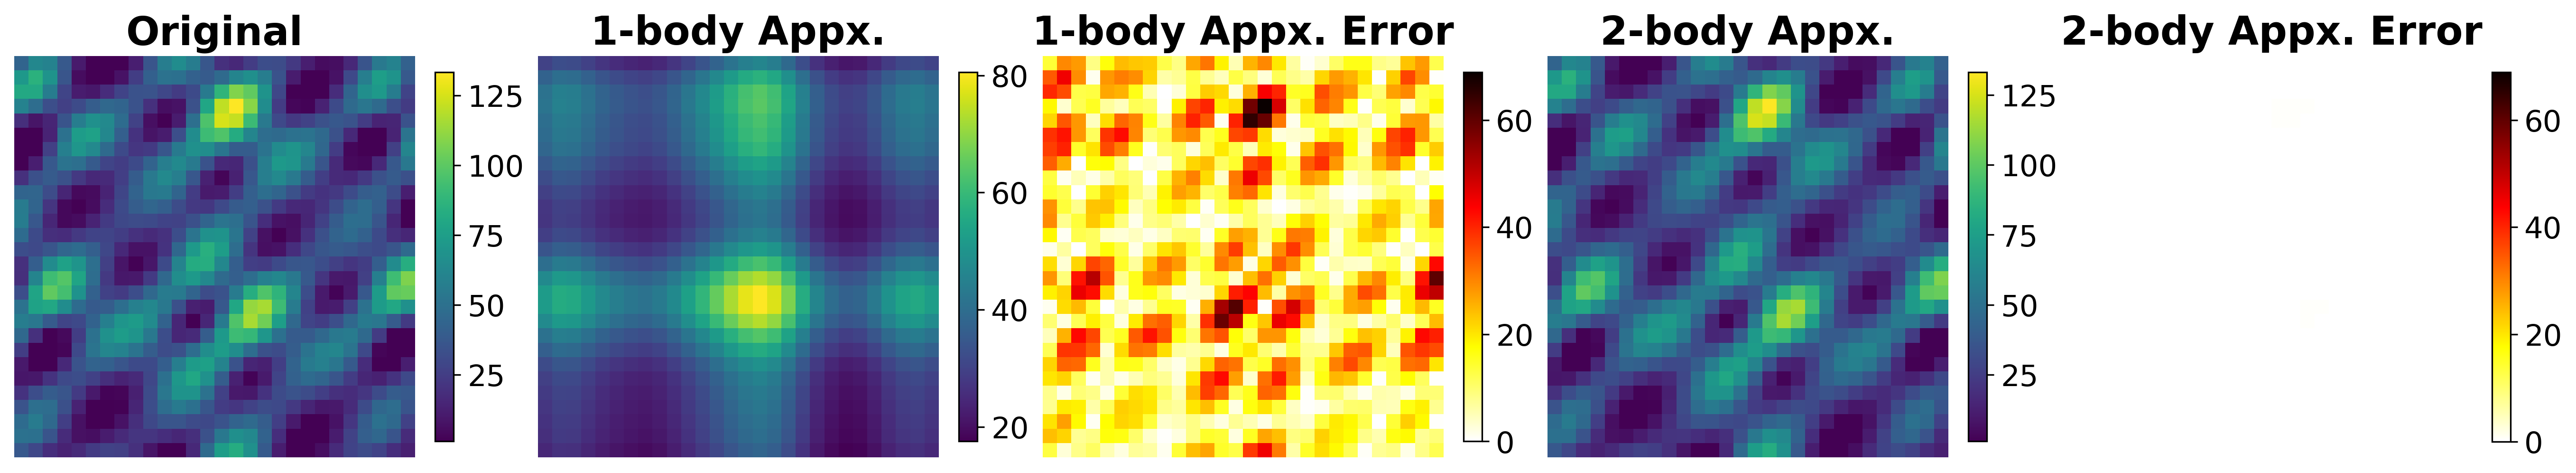

In [3]:
# Pre-calc residuals
res_sep_1 = np.abs(X_sep_enhanced - approx_1body_sep_enh)
res_sep_2 = np.abs(X_sep_enhanced - approx_2body_sep_enh)
res_non_1 = np.abs(X_nonsep_enhanced - approx_1body_nonsep_enh)
res_non_2 = np.abs(X_nonsep_enhanced - approx_2body_nonsep_enh)
vmax_sep = max(res_sep_1.max(), res_sep_2.max())
vmax_non = max(res_non_1.max(), res_non_2.max())

# --- 4A: Separable Data Analysis ---
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), constrained_layout=True)

# 1. Original
im = axes[0].imshow(X_sep_enhanced, cmap='viridis')
axes[0].set_title('Original', fontweight='bold')
plt.colorbar(im, ax=axes[0], fraction=0.046)

# 2. 1-body Approx
im = axes[1].imshow(approx_1body_sep_enh, cmap='viridis')
mse = np.mean((X_sep_enhanced - approx_1body_sep_enh)**2)
axes[1].set_title(f'1-body Appx.', fontweight='bold')
plt.colorbar(im, ax=axes[1], fraction=0.046)

# 3. 1-body Error
im = axes[2].imshow(res_sep_1, cmap='Reds', vmin=0, vmax=vmax_sep)
axes[2].set_title('1-body Appx. Error', fontweight='bold')
plt.colorbar(im, ax=axes[2], fraction=0.046)

# 4. 2-body Approx
im = axes[3].imshow(approx_2body_sep_enh, cmap='viridis')
mse = np.mean((X_sep_enhanced - approx_2body_sep_enh)**2)
axes[3].set_title(f'2-body Appx.', fontweight='bold')
plt.colorbar(im, ax=axes[3], fraction=0.046)

# 5. 2-body Error
im = axes[4].imshow(res_sep_2, cmap='Reds', vmin=0, vmax=vmax_sep)
axes[4].set_title('2-body Appx. Error', fontweight='bold')
plt.colorbar(im, ax=axes[4], fraction=0.046)

for ax in axes: ax.axis('off')
plt.savefig('Figures/rebuttal/weak_strong_interaction_separable.pdf')
plt.show()


# --- 4B: Non-Separable Data Analysis ---
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), constrained_layout=True)

# 1. Original
im = axes[0].imshow(X_nonsep_enhanced, cmap='viridis')
axes[0].set_title('Original', fontweight='bold')
plt.colorbar(im, ax=axes[0], fraction=0.046)

# 2. 1-body Approx
im = axes[1].imshow(approx_1body_nonsep_enh, cmap='viridis')
mse = np.mean((X_nonsep_enhanced - approx_1body_nonsep_enh)**2)
axes[1].set_title(f'1-body Appx.', fontweight='bold')
plt.colorbar(im, ax=axes[1], fraction=0.046)

# 3. 1-body Error
im = axes[2].imshow(res_non_1, cmap='hot_r', vmin=0, vmax=vmax_non)
axes[2].set_title('1-body Appx. Error', fontweight='bold')
plt.colorbar(im, ax=axes[2], fraction=0.046)

# 4. 2-body Approx
im = axes[3].imshow(approx_2body_nonsep_enh, cmap='viridis')
mse = np.mean((X_nonsep_enhanced - approx_2body_nonsep_enh)**2)
axes[3].set_title(f'2-body Appx.', fontweight='bold')
plt.colorbar(im, ax=axes[3], fraction=0.046)

# 5. 2-body Error
im = axes[4].imshow(res_non_2, cmap='hot_r', vmin=0, vmax=vmax_non)
axes[4].set_title('2-body Appx. Error', fontweight='bold')
plt.colorbar(im, ax=axes[4], fraction=0.046)

for ax in axes: ax.axis('off')
plt.savefig('Figures/rebuttal/weak_strong_interaction_nonseparable.pdf')
plt.show()

# Linear Interpolation

In [4]:
# 1. Create Data Points
S = (28, 28)
B_2body_aug = ld.default_B(S, 2, np)

def create_controlled_interaction_images(size=28, alpha=0.5, n_samples=30):
    """
    Create images with controlled interaction strength. (Copied from Exp 2)
    alpha = 0: Perfectly separable
    alpha = 1: Strong interactions
    """
    images = []
    for _ in range(n_samples):
        i = np.arange(size)
        j = np.arange(size)

        # Base separable component
        freq_row = np.random.choice([2, 3, 4])
        freq_col = np.random.choice([2, 3, 4])
        phase_row = np.random.uniform(0, 2*np.pi)
        phase_col = np.random.uniform(0, 2*np.pi)

        row_effect = 1 + 0.7 * np.sin(2 * np.pi * freq_row * i / size + phase_row)
        col_effect = 1 + 0.7 * np.sin(2 * np.pi * freq_col * j / size + phase_col)

        img_separable = 50 * row_effect[:, np.newaxis] * col_effect[np.newaxis, :]

        # Non-separable interaction terms
        II, JJ = np.meshgrid(i, j, indexing='ij')
        interaction1 = np.sin(2 * np.pi * (II + JJ) / (2 * size))
        interaction2 = np.cos(2 * np.pi * II / size) * np.cos(2 * np.pi * JJ / size)
        interaction3 = np.sin(2 * np.pi * II * JJ / (size**2))

        # Combine with weight α
        img = img_separable * (1 + alpha * (0.4 * interaction1 + 0.3 * interaction2 + 0.2 * interaction3))

        img = np.maximum(img, 1.0)
        img = img / img.sum() * np.random.uniform(800, 1200)

        images.append(img)
    return np.array(images)

# Data Point 1 (Separable, α=0.0)
np.random.seed(42) # Use fixed seed for consistency
X_sep_aug = create_controlled_interaction_images(S[0], alpha=0.0, n_samples=1)[0] + eps
# Data Point 2 (Non-Separable, α=1.0)
np.random.seed(43) # Use different seed for a different base pattern
X_nonsep_aug = create_controlled_interaction_images(S[0], alpha=1.0, n_samples=1)[0] + eps

# 2. Forward Projection (Encoding)
print("Encoding α=0.0 and α=1.0 images to l=2 latent space...")
_, _, scale_sep, _, theta_sep = ld.LD(
    X_sep_aug, B=B_2body_aug, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False
)
_, _, scale_nonsep, _, theta_nonsep = ld.LD(
    X_nonsep_aug, B=B_2body_aug, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False
)
print("Encoding complete.")

# 3. Interpolation, Decoding, and Quantitative Analysis
print("Running latent interpolation, pixel interpolation, and quantitative analysis...")
alphas = np.linspace(0, 1, 5) # 5 steps

# Storage for results
latent_augmented_images = []
pixel_augmented_images = []
mse_1body_latent = []
mse_2body_latent = []
mse_1body_pixel = []
mse_2body_pixel = []

B_1body_test = ld.default_B(S, 1, np) # We need this to *test* the energy

for alpha in alphas:
    # === LATENT INTERPOLATION ===
    # 3a. Latent Augmentation (Interpolation)
    theta_mix = (1 - alpha) * theta_sep + alpha * theta_nonsep
    scale_mix = (1 - alpha) * scale_sep + alpha * scale_nonsep

    # 3b. Backward Projection (Decoding)
    Q_mix = ld.get_Q(theta_mix, scipy_logsumexp, eps=eps, xp=np)
    X_aug_latent = (Q_mix * scale_mix).reshape(S)
    latent_augmented_images.append(X_aug_latent)

    # 3c. Test Interaction Energy for Latent Interpolation
    _, _, s1_lat, Q1_lat, _ = ld.LD(X_aug_latent, B=B_1body_test, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
    mse_1body_latent.append(np.mean((X_aug_latent - (Q1_lat * s1_lat))**2))

    _, _, s2_lat, Q2_lat, _ = ld.LD(X_aug_latent, B=B_2body_aug, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
    mse_2body_latent.append(np.mean((X_aug_latent - (Q2_lat * s2_lat))**2))

    # === PIXEL INTERPOLATION (for comparison) ===
    X_aug_pixel = (1 - alpha) * X_sep_aug + alpha * X_nonsep_aug
    pixel_augmented_images.append(X_aug_pixel)

    # 3d. Test Interaction Energy for Pixel Interpolation
    _, _, s1_pix, Q1_pix, _ = ld.LD(X_aug_pixel, B=B_1body_test, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
    mse_1body_pixel.append(np.mean((X_aug_pixel - (Q1_pix * s1_pix))**2))

    _, _, s2_pix, Q2_pix, _ = ld.LD(X_aug_pixel, B=B_2body_aug, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
    mse_2body_pixel.append(np.mean((X_aug_pixel - (Q2_pix * s2_pix))**2))

Encoding α=0.0 and α=1.0 images to l=2 latent space...
Encoding complete.
Running latent interpolation, pixel interpolation, and quantitative analysis...


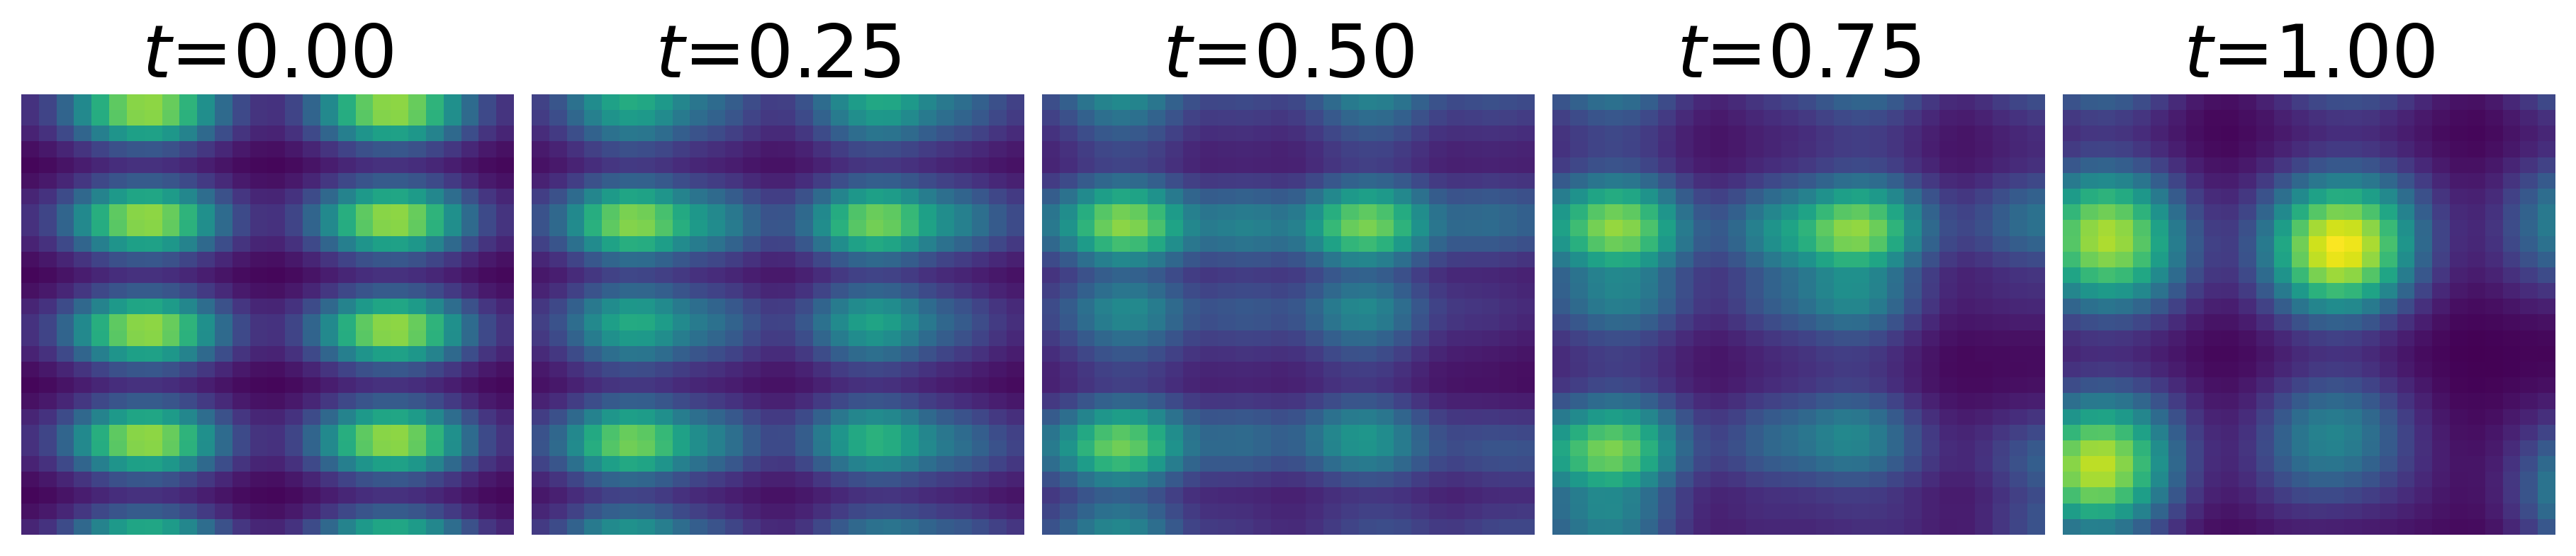

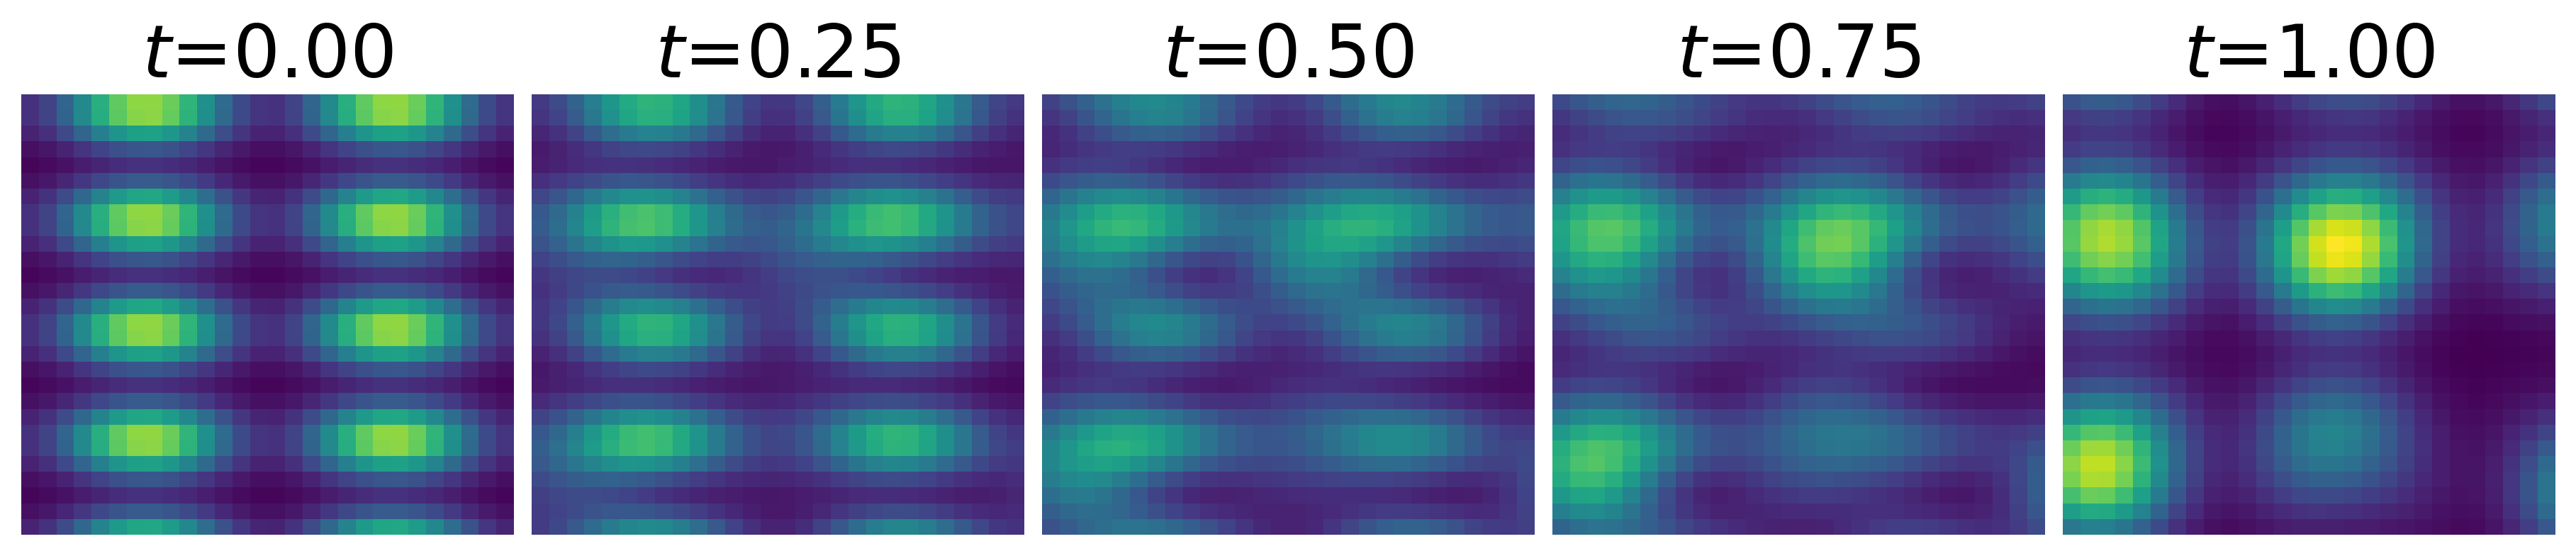

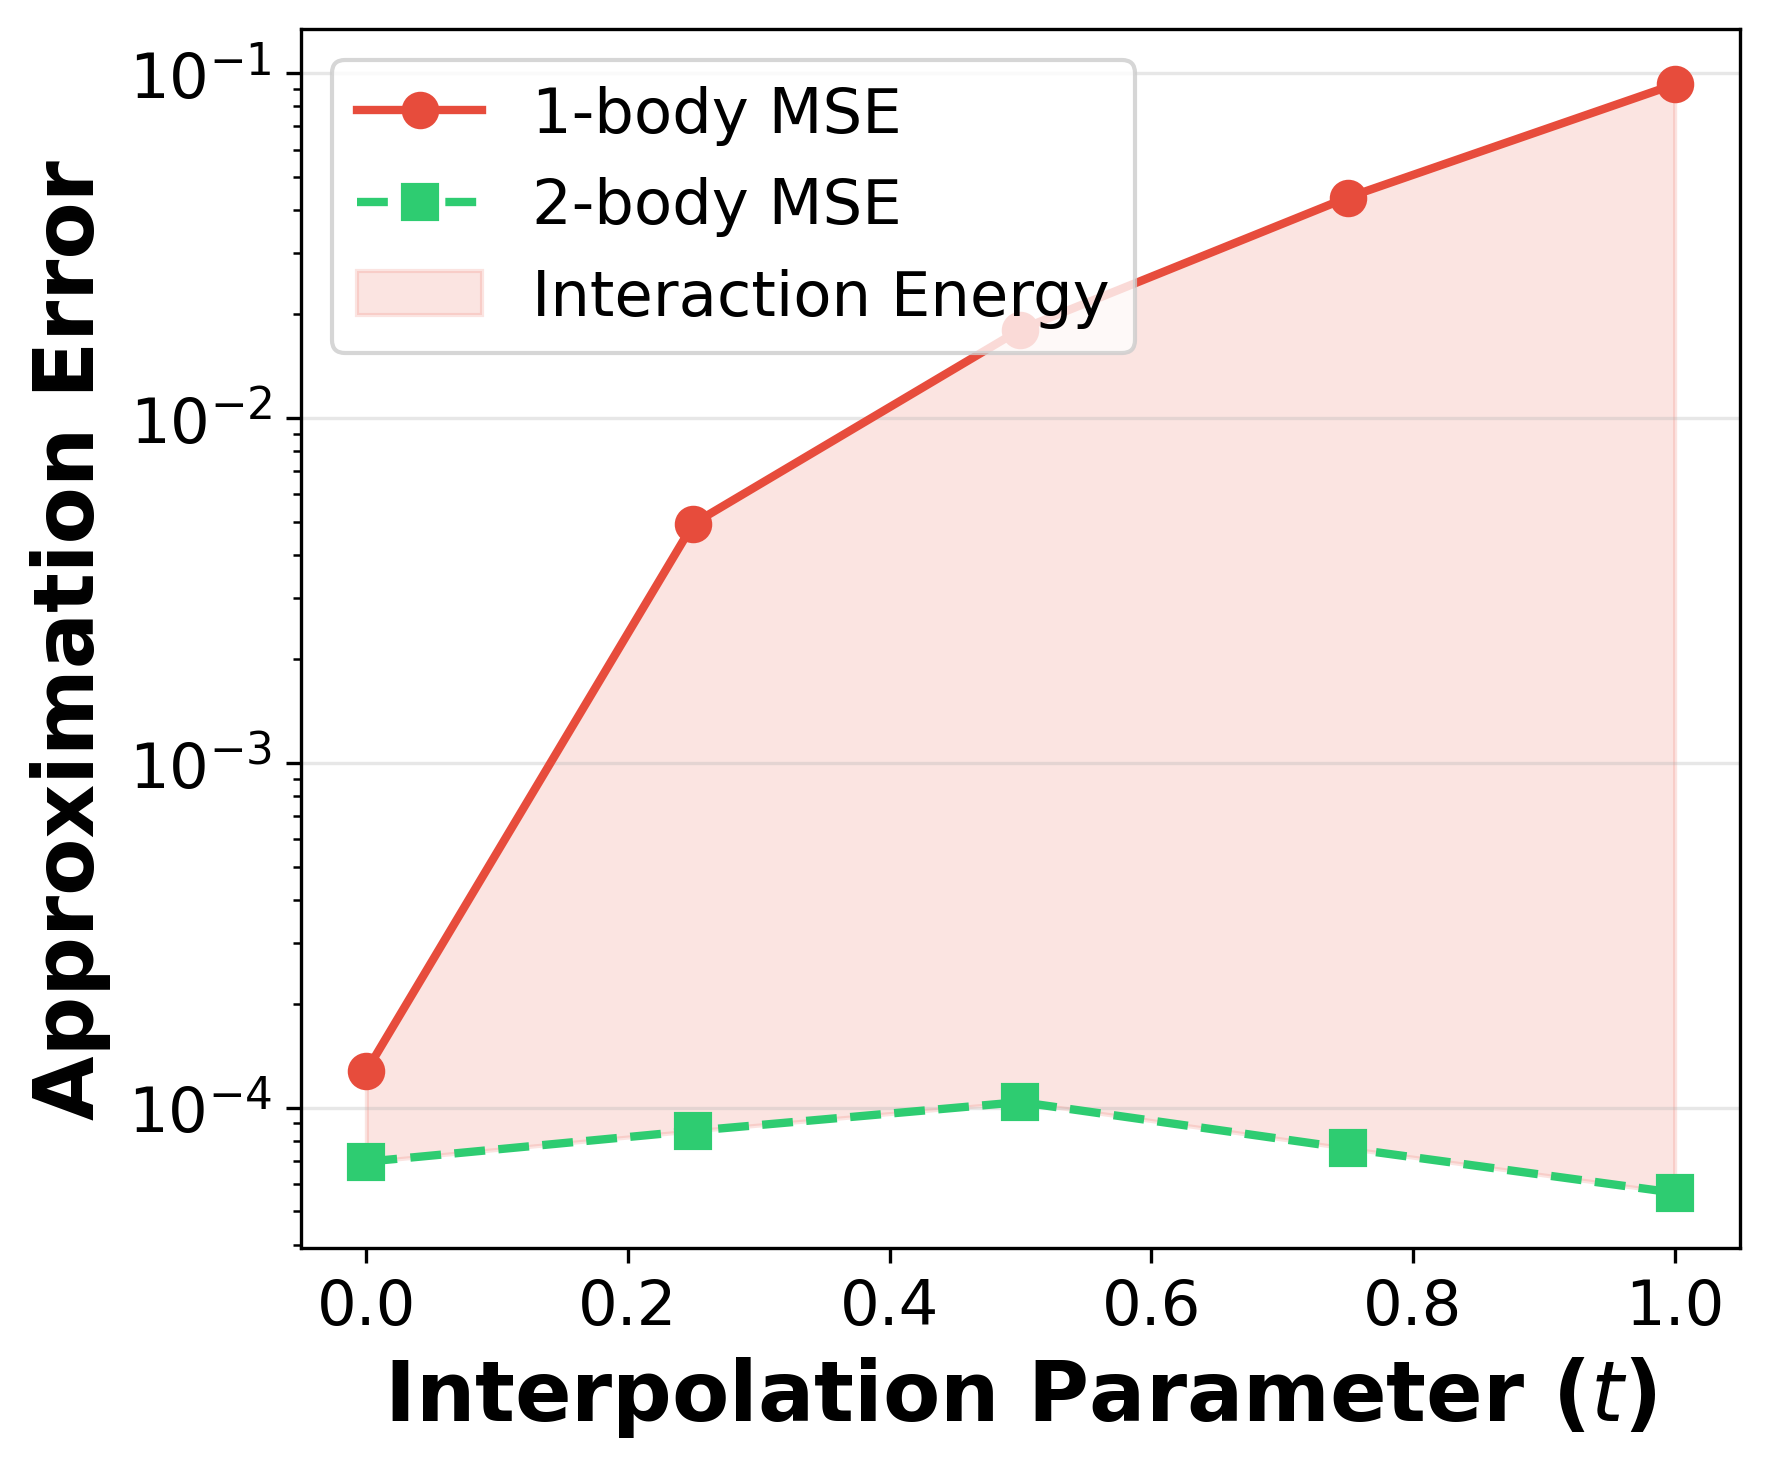

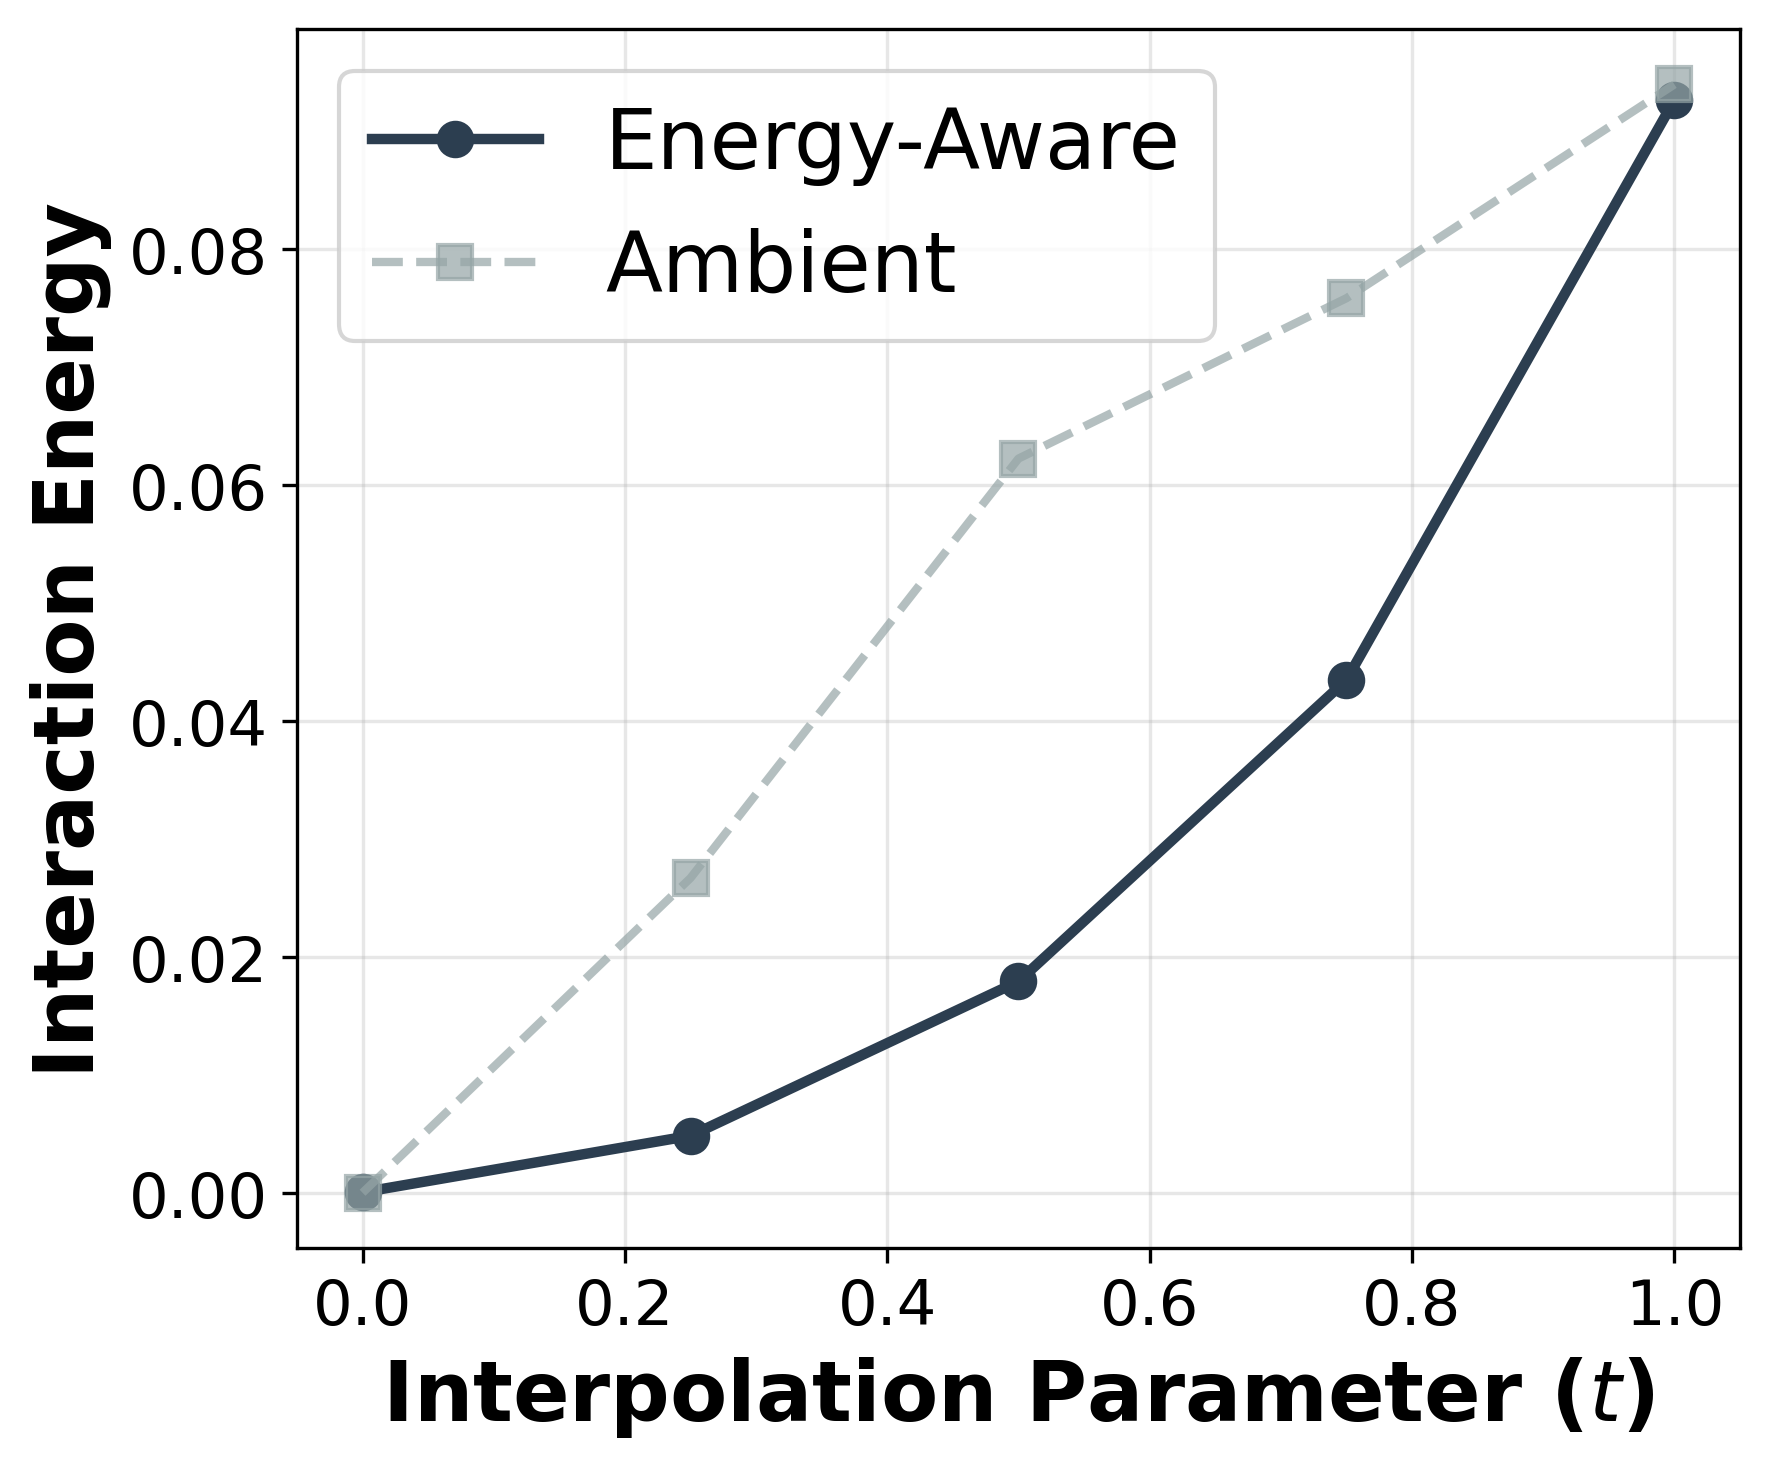

In [5]:
all_imgs = latent_augmented_images + pixel_augmented_images
vmin = min([img.min() for img in all_imgs])
vmax = max([img.max() for img in all_imgs])

# --- 1A: Latent Space Interpolation Row ---
fig, axes = plt.subplots(1, 5, figsize=(12, 2.5), constrained_layout=True)
for i, img in enumerate(latent_augmented_images):
    ax = axes[i]
    ax.imshow(img, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(f"$t$={alphas[i]:.2f}", fontsize=25)
    ax.axis('off')

plt.savefig('Figures/rebuttal/linear_interpolation_pnl.pdf', bbox_inches='tight')
plt.show()

# --- 1B: Pixel Space Interpolation Row ---
fig, axes = plt.subplots(1, 5, figsize=(12, 2.5), constrained_layout=True)
for i, img in enumerate(pixel_augmented_images):
    ax = axes[i]
    ax.imshow(img, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(f"$t$={alphas[i]:.2f}", fontsize=25)
    ax.axis('off')

plt.savefig('Figures/rebuttal/linear_interpolation_ambient.pdf', bbox_inches='tight')
plt.show()

# --- 1C: Latent Approximation MSE ---
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(alphas, mse_1body_latent, 'o-', label='1-body MSE', color='#e74c3c', markersize=8, linewidth=2)
ax.plot(alphas, mse_2body_latent, 's--', label='2-body MSE', color='#2ecc71', markersize=8, linewidth=2)
ax.fill_between(alphas, mse_1body_latent, mse_2body_latent, color='#e74c3c', alpha=0.15, label='Interaction Energy')

ax.set_xlabel("Interpolation Parameter ($t$)", fontweight='bold')
ax.set_ylabel("Approximation Error", fontweight='bold')
ax.set_yscale('log')
ax.legend(loc='upper left', frameon=True, fontsize=15)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Figures/rebuttal/linear_interpolation_error.pdf')
plt.show()

# --- 1D: Interaction Energy Gap Comparison ---
fig, ax = plt.subplots(figsize=(6, 5))
interaction_energy_latent = np.array(mse_1body_latent) - np.array(mse_2body_latent)
interaction_energy_pixel = np.array(mse_1body_pixel) - np.array(mse_2body_pixel)

ax.plot(alphas, interaction_energy_latent, 'o-', label='Energy-Aware', color='#2c3e50', markersize=8, linewidth=2.5)
ax.plot(alphas, interaction_energy_pixel, 's--', label='Ambient', color='#95a5a6', markersize=8, linewidth=2, alpha=0.7)

ax.set_xlabel("Interpolation Parameter ($t$)", fontweight='bold')
ax.set_ylabel("Interaction Energy", fontweight='bold')
ax.legend(loc='best', frameon=True, fontsize=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figures/rebuttal/linear_interpolation_gap.pdf')
plt.show()

# Time-Series Data

In [6]:

def create_separable_spectrogram(size=28):
    """Creates a 2D spectrogram P[t, f] = g(t) * h(f) (1-body)"""
    t = np.arange(size) # Time
    f = np.arange(size) # Frequency
    time_effect = 1 + 0.8 * np.sin(2 * np.pi * np.random.choice([2,3]) * t / size + np.random.uniform(0, 2*np.pi))
    freq_effect = 1 + 0.8 * np.sin(2 * np.pi * np.random.choice([4,5]) * f / size + np.random.uniform(0, 2*np.pi))
    spec = 100 * time_effect[:, np.newaxis] * freq_effect[np.newaxis, :]
    return spec + eps

def create_nonseparable_spectrogram(size=28):
    """Creates a 2D spectrogram with time-frequency interactions (2-body) - ENHANCED for visibility"""
    t = np.arange(size) # Time
    f = np.arange(size) # Frequency
    time_effect = 1 + 0.5 * np.sin(2 * np.pi * np.random.choice([2,3]) * t / size + np.random.uniform(0, 2*np.pi))
    freq_effect = 1 + 0.5 * np.sin(2 * np.pi * np.random.choice([2,3]) * f / size + np.random.uniform(0, 2*np.pi))
    spec = 50 * time_effect[:, np.newaxis] * freq_effect[np.newaxis, :]
    TT, FF = np.meshgrid(t, f, indexing='ij')
    # ENHANCED: Stronger chirp pattern for visual clarity
    chirp_pattern = np.sin(2 * np.pi * (TT + FF) / (2 * size))
    cross_chirp = np.cos(2 * np.pi * (TT - FF) / (2 * size))
    spec = np.maximum(spec * (1 + 0.7 * chirp_pattern + 0.4 * cross_chirp), 1.0)
    return spec + eps

# 1. Generate data
S_ts = (32, 32)
X_sep_ts = create_separable_spectrogram(S_ts[0])
X_nonsep_ts = create_nonseparable_spectrogram(S_ts[0])

# 2. Define bases (same as before)
B_1body_ts = ld.default_B(S_ts, 1, np)
B_2body_ts = ld.default_B(S_ts, 2, np)

# 3. Run all approximations
# Separable data
_, _, scale_sep1_ts, Q_sep1_ts, _ = ld.LD(X_sep_ts, B=B_1body_ts, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
approx_sep1_ts = Q_sep1_ts * scale_sep1_ts
_, _, scale_sep2_ts, Q_sep2_ts, _ = ld.LD(X_sep_ts, B=B_2body_ts, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
approx_sep2_ts = Q_sep2_ts * scale_sep2_ts

# Non-separable data
_, _, scale_non1_ts, Q_non1_ts, _ = ld.LD(X_nonsep_ts, B=B_1body_ts, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
approx_non1_ts = Q_non1_ts * scale_non1_ts
_, _, scale_non2_ts, Q_non2_ts, _ = ld.LD(X_nonsep_ts, B=B_2body_ts, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
approx_non2_ts = Q_non2_ts * scale_non2_ts

ts_nonsep = X_nonsep_ts.flatten()[600:]
ts_approx_1body = approx_non1_ts.flatten()[600:]
ts_approx_2body = approx_non2_ts.flatten()[600:]

# Calculate errors
ts_error_1body = np.abs(ts_nonsep - ts_approx_1body)
ts_error_2body = np.abs(ts_nonsep - ts_approx_2body)

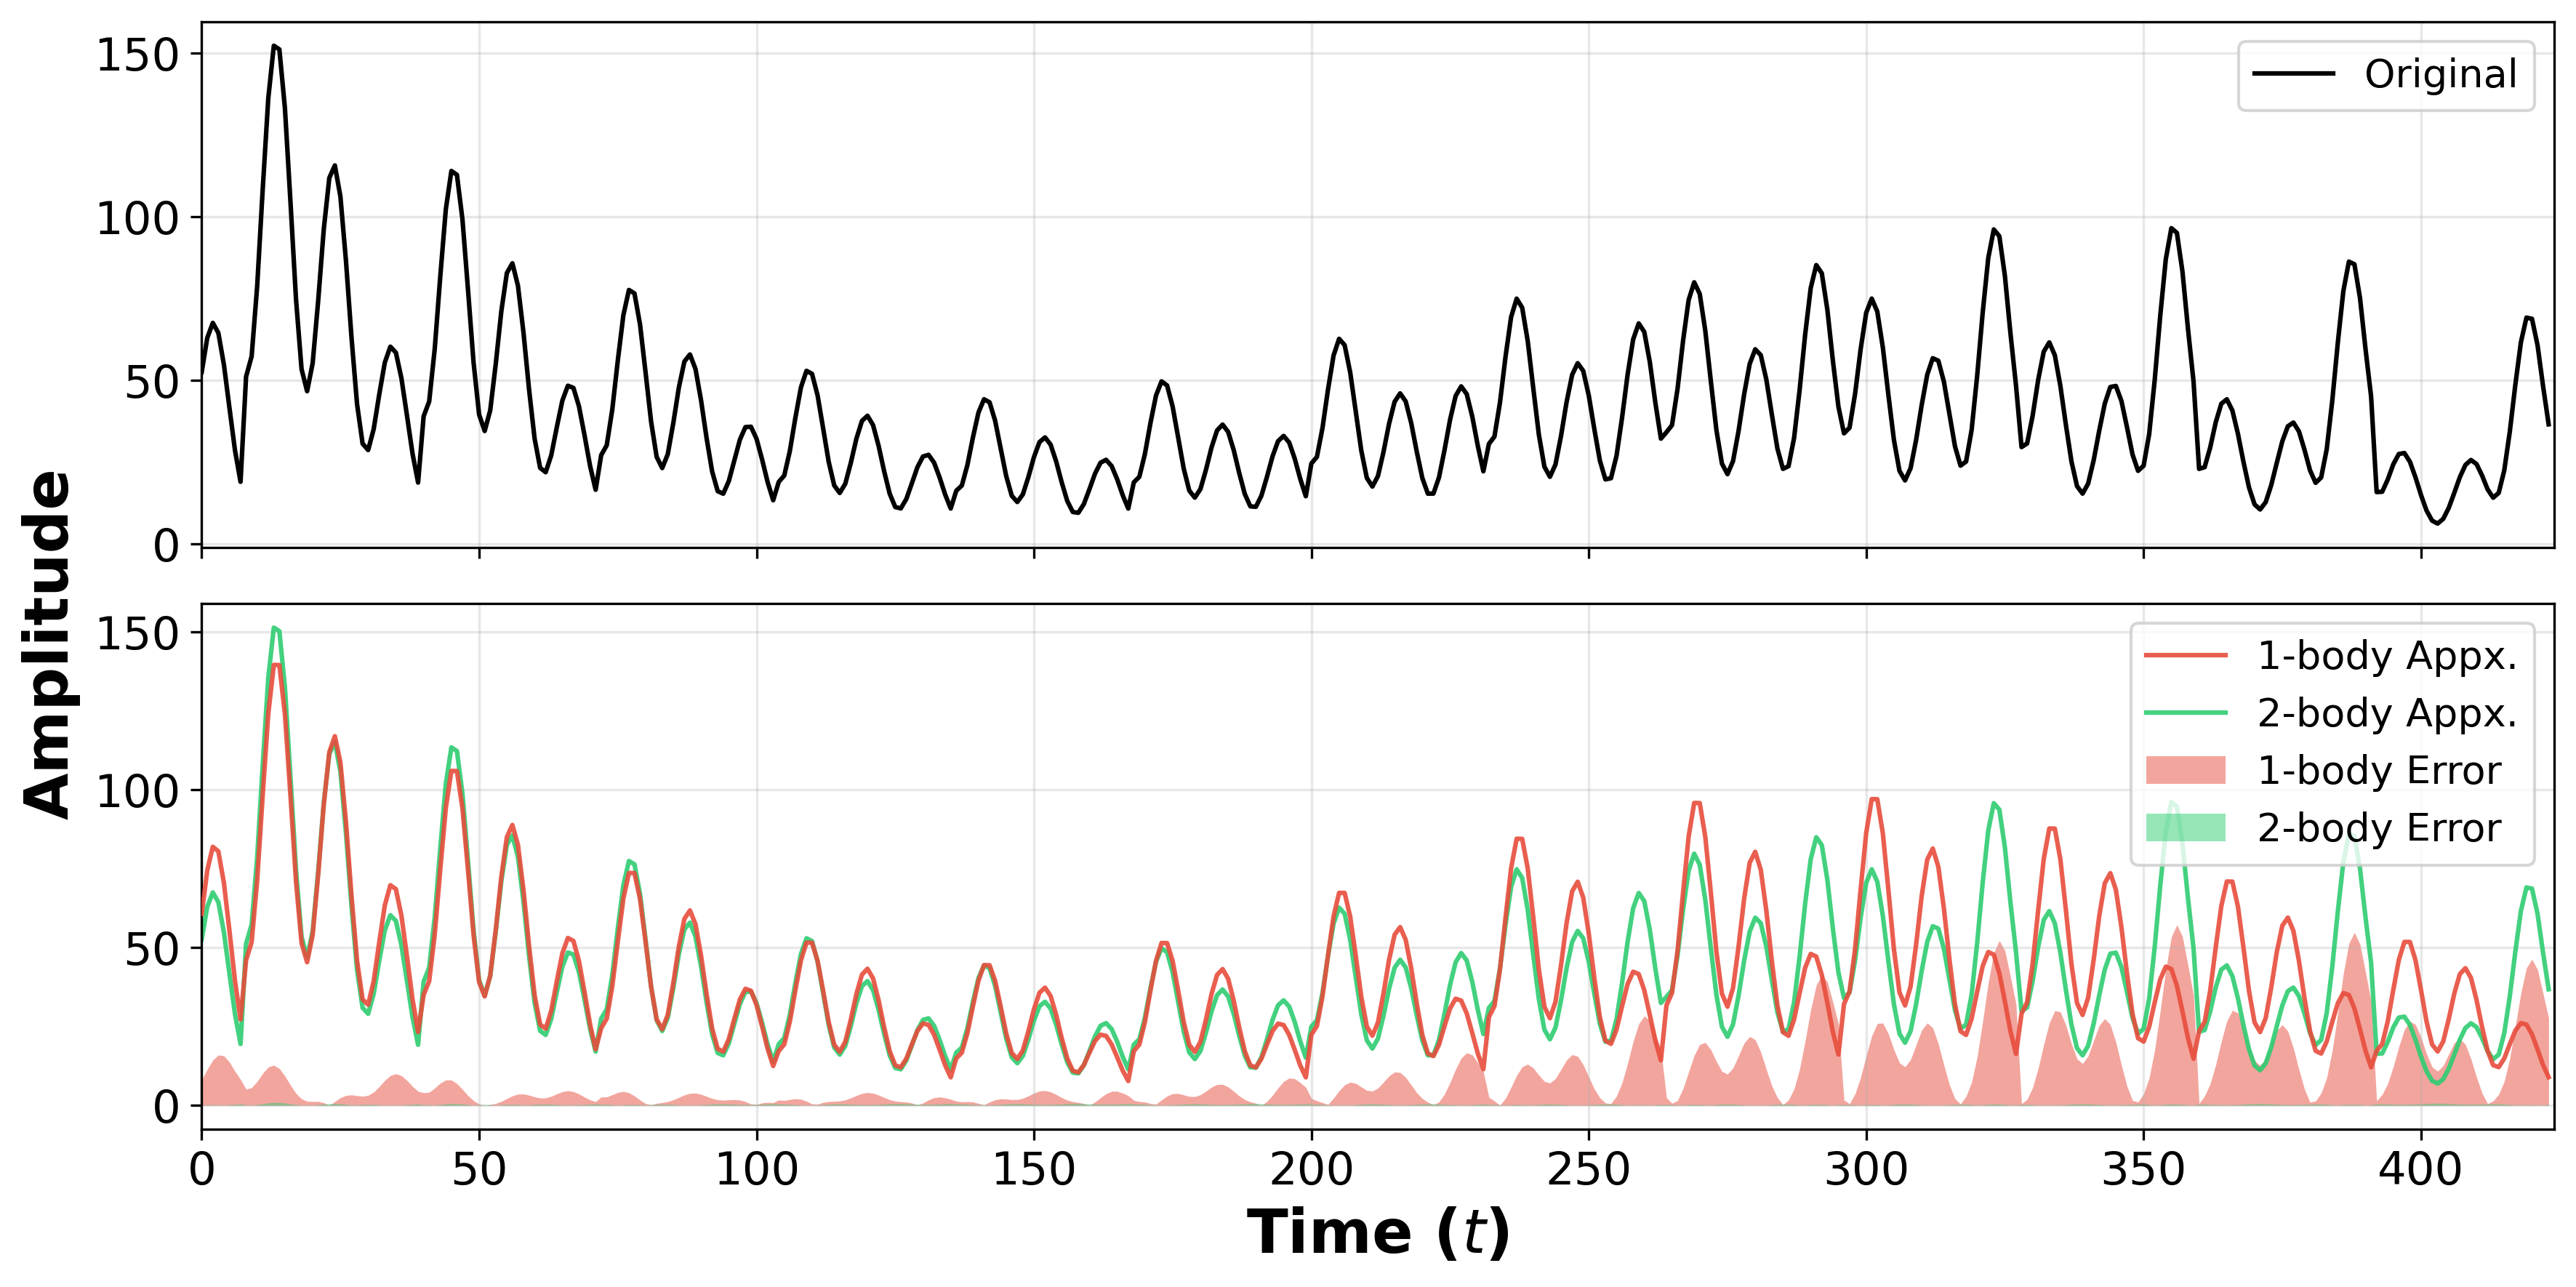

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Top: Original Signal
ax1.plot(ts_nonsep, color='black', linewidth=1.5, label='Original')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=13)

# Bottom: Approximation + Error Plot
ax2.plot(ts_approx_1body, color='#e74c3c', linewidth=1.5, label='1-body Appx.', alpha=0.9, zorder=3)
ax2.plot(ts_approx_2body, color='#2ecc71', linewidth=1.5, label='2-body Appx.', alpha=0.9, zorder=2)

# Error bands (behind, filling from 0 to error value)
ax2.fill_between(range(len(ts_error_1body)), ts_error_1body,
                color='#e74c3c', alpha=0.5, linewidth=0,
                label='1-body Error', zorder=1)
ax2.fill_between(range(len(ts_error_2body)), ts_error_2body,
                color='#2ecc71', alpha=0.5, linewidth=0,
                label='2-body Error', zorder=1)

ax2.set_xlabel("Time ($t$)", fontweight='bold')
ax2.grid(True, alpha=0.3, zorder=0)
ax2.set_xlim(0, len(ts_nonsep))
ax2.legend(loc='upper right', fontsize=13)

# Align y-axis ticks with consistent intervals
from matplotlib.ticker import MultipleLocator
# Use interval of 25 for consistent spacing
ax1.yaxis.set_major_locator(MultipleLocator(50))
ax2.yaxis.set_major_locator(MultipleLocator(50))

# Single unified y-label
fig.supylabel("Amplitude", fontweight='bold', fontsize=20)

plt.tight_layout()
plt.savefig('Figures/rebuttal/time_series_combined.pdf')
plt.show()

# Approximation Quality Across Interaction Strengths

In [8]:
# Generate data with varying alpha values for visualization
alphas_viz = [0.0, 0.25, 0.5, 0.75, 1.0]
n_samples_per_alpha = 10

# Create data dictionary
data_by_alpha = {}
for alpha in alphas_viz:
    np.random.seed(100 + int(alpha*10))  # Different seed per alpha for variety
    data_by_alpha[alpha] = create_controlled_interaction_images(S[0], alpha=alpha, n_samples=n_samples_per_alpha)

# CRITICAL FIX: Create bases that match the actual image size (64x64)
# The B_1body and B_2body from cell 1 are for (28, 28), but our images are (64, 64)!
B_1body_viz = ld.default_B(S, 1, np)  # Create 64x64 1-body basis
B_2body_viz = ld.default_B(S, 2, np)  # Create 64x64 2-body basis

# Use a single sample index across all alphas for consistency
sample_idx = 3

# Approximate for visualization (using the correct 64x64 bases!)
approximations = {}
for alpha in alphas_viz:
    img = data_by_alpha[alpha][sample_idx]

    # 1-body approximation (FIXED: Use B_1body_viz instead of B_1body)
    _, _, scaleX_1, Q_1, _ = ld.LD(img, B=B_1body_viz, verbose=False,
                                     n_iter=500, lr=0.1, eps=eps, gpu=False)
    approx_1body = Q_1 * scaleX_1

    # 2-body approximation (FIXED: Use B_2body_viz instead of B_2body)
    _, _, scaleX_2, Q_2, _ = ld.LD(img, B=B_2body_viz, verbose=False,
                                     n_iter=500, lr=0.1, eps=eps, gpu=False)
    approx_2body = Q_2 * scaleX_2

    approximations[alpha] = {
        'original': img,
        '1-body': approx_1body,
        '2-body': approx_2body,
        'mse_1body': np.mean((img - approx_1body)**2),
        'mse_2body': np.mean((img - approx_2body)**2)
    }

# Find global vmin/vmax for consistent coloring
all_originals = [approximations[a]['original'] for a in alphas_viz]
vmin = min([img.min() for img in all_originals])
vmax = max([img.max() for img in all_originals])

# Find max residual for consistent error coloring
max_residual_1body = max([np.abs(approximations[a]['original'] - approximations[a]['1-body']).max()
                          for a in alphas_viz])
max_residual_2body = max([np.abs(approximations[a]['original'] - approximations[a]['2-body']).max()
                          for a in alphas_viz])
max_residual = max(max_residual_1body, max_residual_2body)

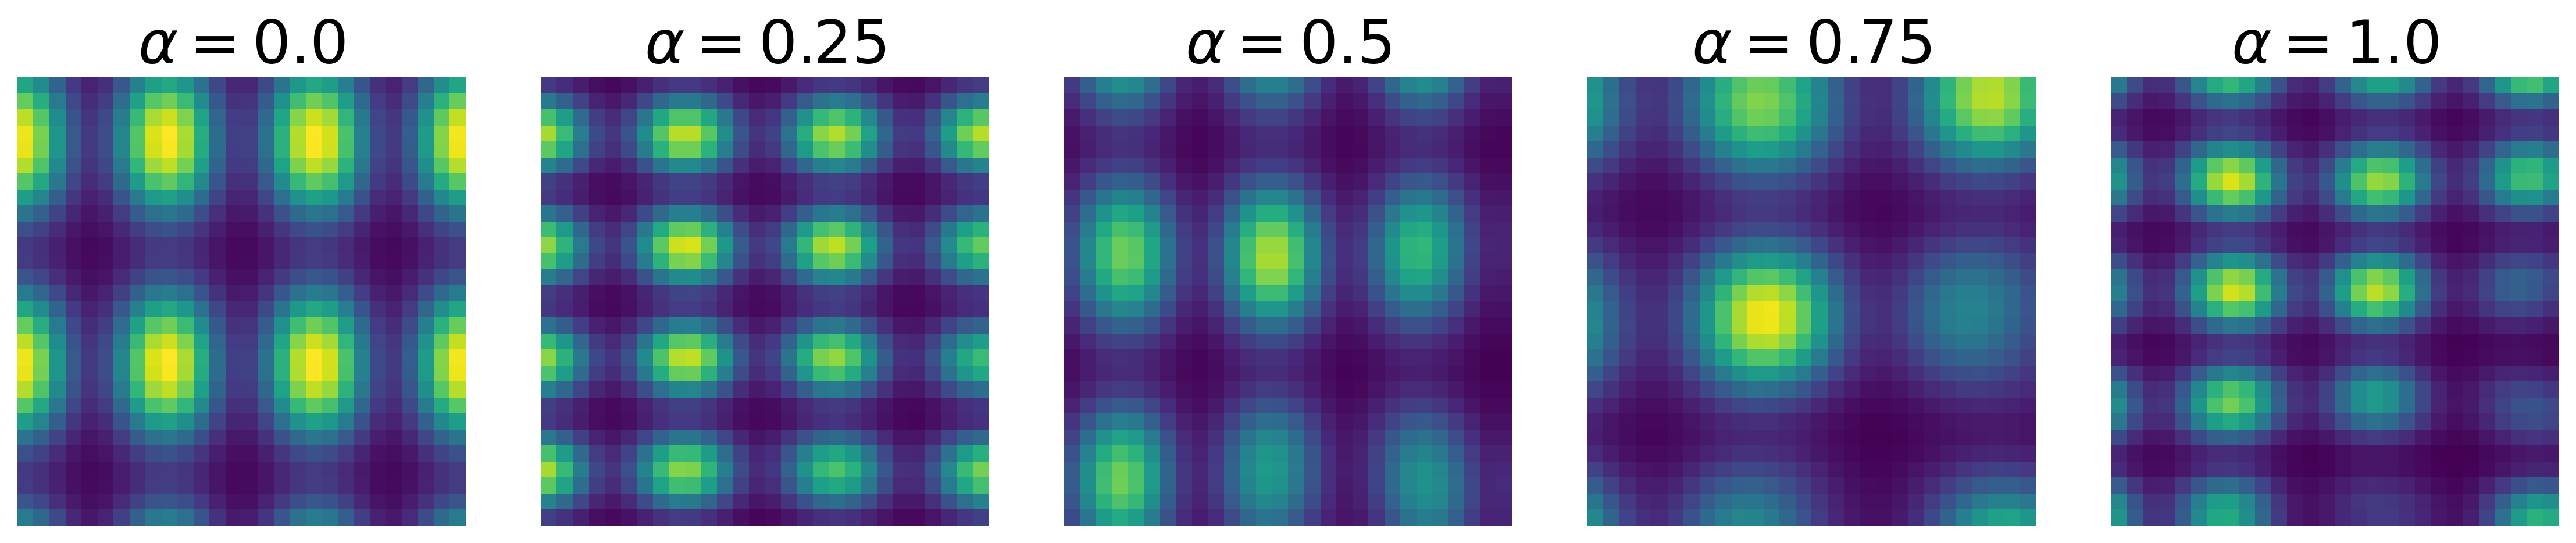

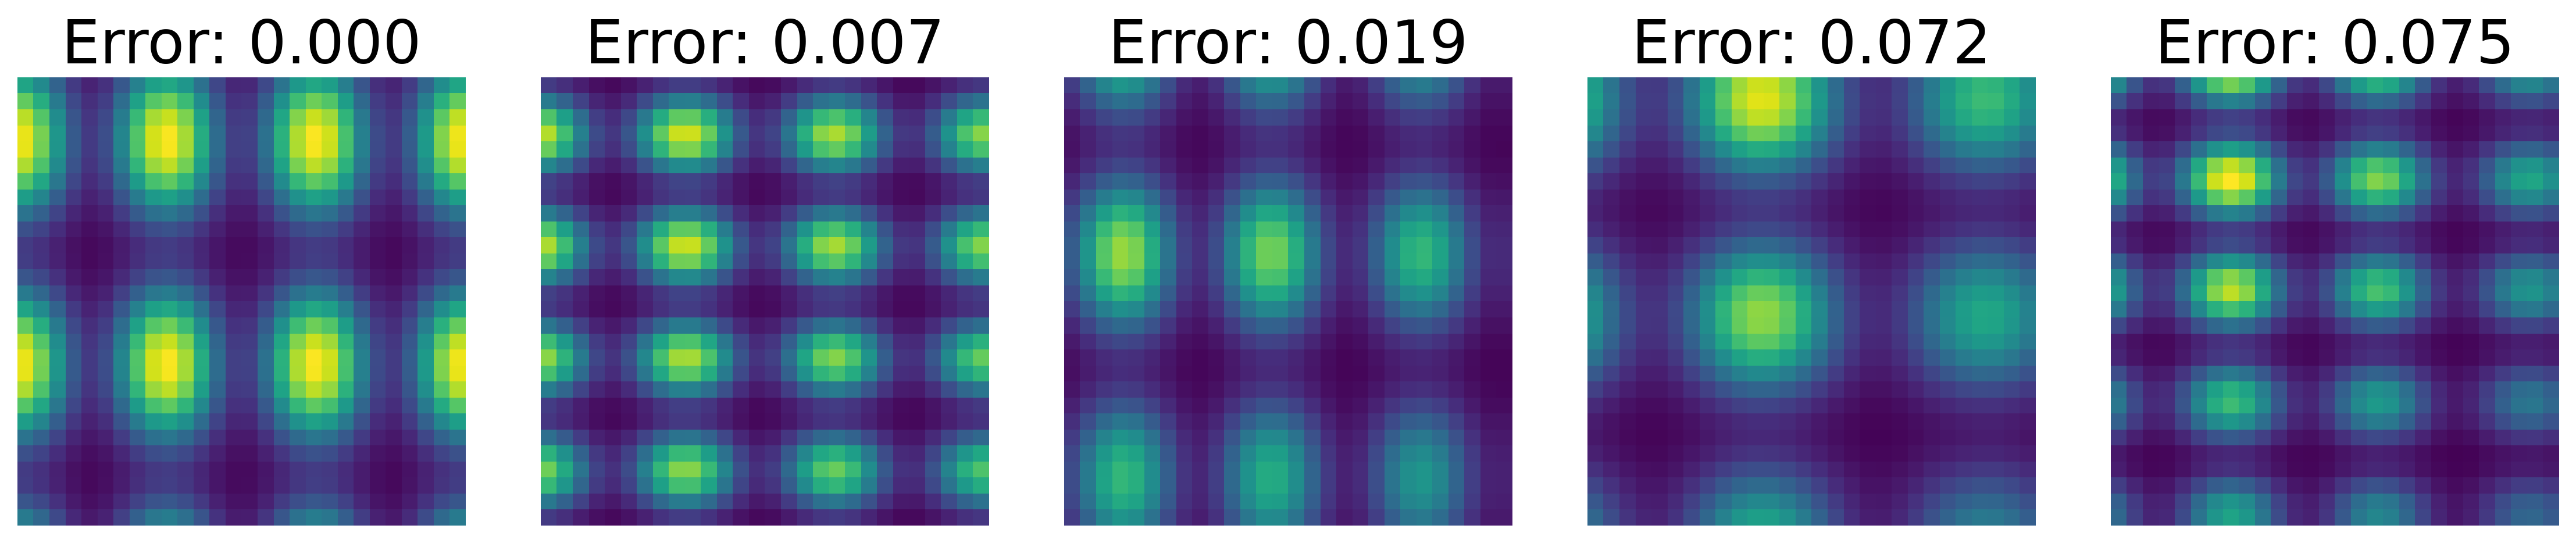

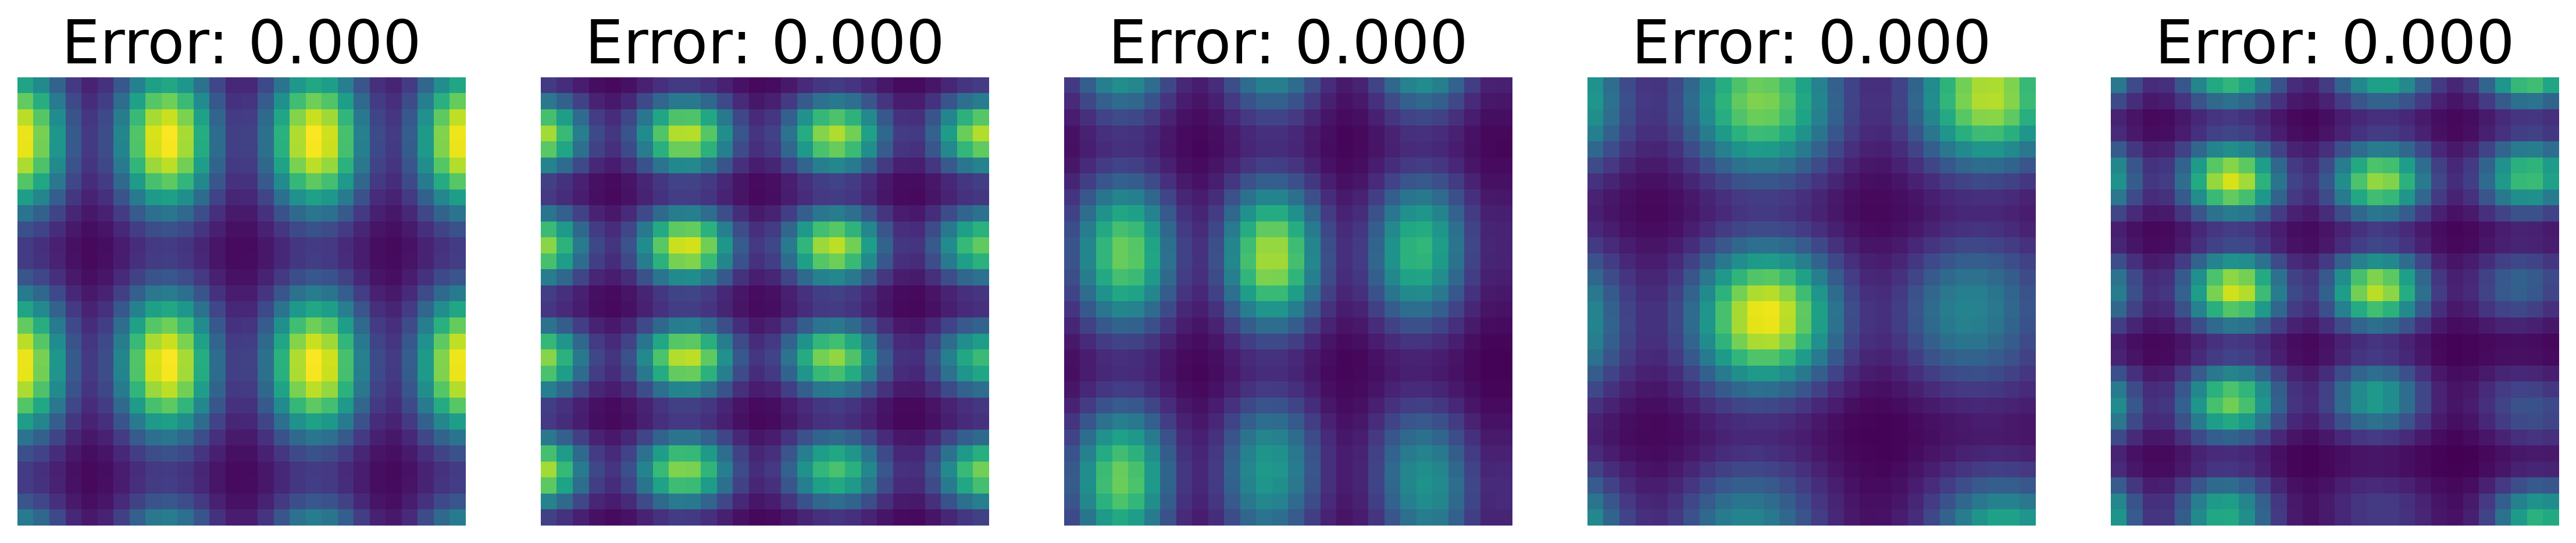

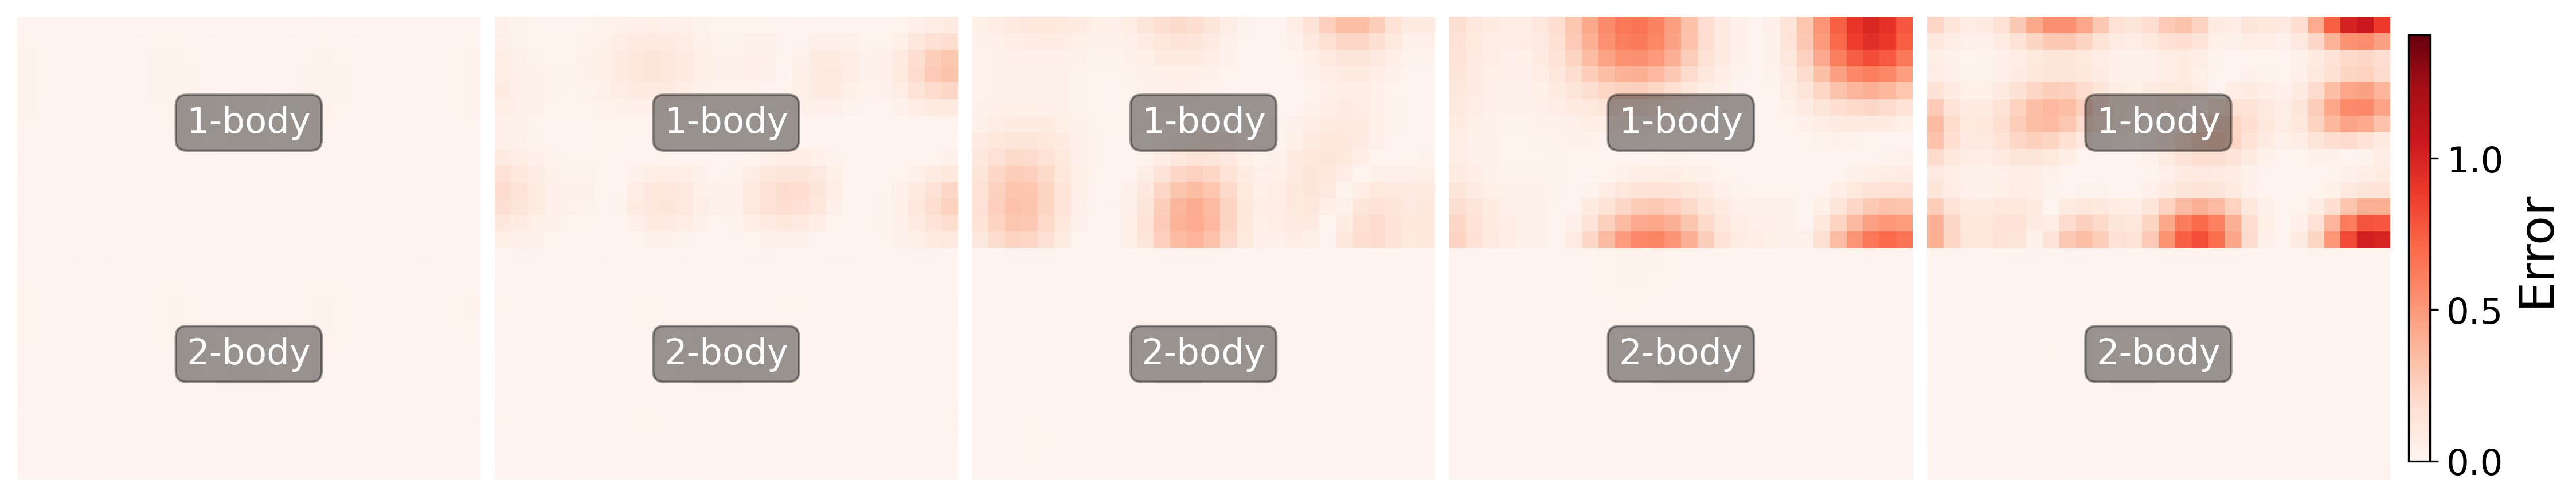

In [9]:
# Shared parameters for consistent visualization
cols = len(alphas_viz)

# --- 2A: Original Images ---
fig, axes = plt.subplots(1, cols, figsize=(15, 3), constrained_layout=True)
for i, alpha in enumerate(alphas_viz):
    ax = axes[i]
    ax.imshow(approximations[alpha]['original'], cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'$\\alpha={alpha}$', fontsize=25)
    ax.axis('off')
    # if i == 0: ax.text(-0.1, 0.5, "Original", transform=ax.transAxes, va='center', ha='right', fontsize=12, rotation=90)

plt.savefig('Figures/rebuttal/interaction_strength_original.pdf', bbox_inches='tight')
plt.show()

# --- 2B: 1-body Approximation ---
fig, axes = plt.subplots(1, cols, figsize=(15, 3), constrained_layout=True)
for i, alpha in enumerate(alphas_viz):
    ax = axes[i]
    ax.imshow(approximations[alpha]['1-body'], cmap='viridis', vmin=vmin, vmax=vmax)
    mse = approximations[alpha]['mse_1body']
    ax.set_title(f'Error: {mse:.3f}', fontsize=25)
    ax.axis('off')
    # if i == 0: ax.text(-0.1, 0.5, "1-body Approx", transform=ax.transAxes, va='center', ha='right', fontsize=12, rotation=90, color='#3498db')

plt.savefig('Figures/rebuttal/interaction_strength_1body.pdf', bbox_inches='tight')
plt.show()

# --- 2C: 2-body Approximation ---
fig, axes = plt.subplots(1, cols, figsize=(15, 3), constrained_layout=True)
for i, alpha in enumerate(alphas_viz):
    ax = axes[i]
    ax.imshow(approximations[alpha]['2-body'], cmap='viridis', vmin=vmin, vmax=vmax)
    mse = approximations[alpha]['mse_2body']
    ax.set_title(f'Error: {mse:.3f}', fontsize=25)
    ax.axis('off')
    # if i == 0: ax.text(-0.1, 0.5, "2-body Approx", transform=ax.transAxes, va='center', ha='right', fontsize=12, rotation=90, color='#e74c3c')

plt.savefig('Figures/rebuttal/interaction_strength_2body.pdf', bbox_inches='tight')
plt.show()

# --- 2D: Residuals (Split View) ---
fig, axes = plt.subplots(1, cols, figsize=(15, 3), constrained_layout=True)
for i, alpha in enumerate(alphas_viz):
    ax = axes[i]
    # Calculate and merge residuals
    res1 = np.abs(approximations[alpha]['original'] - approximations[alpha]['1-body'])
    res2 = np.abs(approximations[alpha]['original'] - approximations[alpha]['2-body'])
    h = res1.shape[0] // 2
    combined = np.vstack([res1[:h, :], res2[h:, :]])

    im = ax.imshow(combined, cmap='Reds', vmin=0, vmax=max_residual)

    # Labels
    ax.text(0.5, 0.75, '1-body', transform=ax.transAxes, ha='center', fontsize=15, color='white', bbox=dict(boxstyle='round', facecolor='black', alpha=0.4))
    ax.text(0.5, 0.25, '2-body', transform=ax.transAxes, ha='center', fontsize=15, color='white', bbox=dict(boxstyle='round', facecolor='black', alpha=0.4))
    ax.axis('off')

    # if i == 0: ax.text(-0.1, 0.5, "Residuals", transform=ax.transAxes, va='center', ha='right', fontsize=12, rotation=90)
    if i == cols - 1: plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Error')

plt.savefig('Figures/rebuttal/interaction_strength_error.pdf', bbox_inches='tight')
plt.show()